# Transfer Learning — Sign Language MNIST (Laboratorio 1)

Transfer Learning aplicado al dataset del Laboratorio 1 (`archive/`). Se comparan dos estrategias de TL contra una CNN entrenada desde cero.

> El notebook de referencia `si3014-transferlearningexcercise.ipynb` usa VGG16 con un dataset de frutas. Acá se toma ese mismo esquema pero con ResNet-18 y el dataset de signos.


---
## 1. Análisis del script si3014

El notebook `si3014-transferlearningexcercise.ipynb` hace Transfer Learning para clasificar 6 tipos de frutas (frescas vs podridas).

### 1.1 Cómo se carga el modelo preentrenado
```python
from torchvision.models import vgg16, VGG16_Weights
weights = VGG16_Weights.DEFAULT
vgg_model = vgg16(weights=weights)
```
Se usa VGG16 preentrenado en ImageNet (1000 clases, ~138M parámetros). Al cargar con `VGG16_Weights.DEFAULT` se descargan los pesos ya entrenados, que traen codificado conocimiento sobre bordes, texturas y formas generales.

### 1.2 Qué capas se congelan o entrenan
```python
vgg_model.requires_grad_(False)   # congela todo el backbone
```
Al inicio se congelan todos los parámetros. La única parte que se entrena es la cabeza nueva:
```python
my_model = nn.Sequential(
    vgg_model.features,        # CONGELADO
    vgg_model.avgpool,         # CONGELADO
    nn.Flatten(),
    vgg_model.classifier[0:3], # CONGELADO
    nn.Linear(4096, 500),      # ENTRENABLE
    nn.ReLU(),
    nn.Linear(500, N_CLASSES)  # ENTRENABLE (6 clases)
)
```
Más adelante, en la sección de fine-tuning, se descongela todo con `vgg_model.requires_grad_(True)` y se baja el learning rate a `1e-4`.

### 1.3 Cómo se prepara el dataset
Las imágenes están organizadas en carpetas por clase (`freshapples/`, `rottenapples/`, etc.). Un `Dataset` personalizado usa `glob.glob` para recolectar las rutas. Las transformaciones redimensionan a 224×224 (lo que espera VGG16) y convierten a `float32`.

### 1.4 Cómo se realiza el entrenamiento
Se usan las funciones `utils.train()` y `utils.validate()` de `training_utils.py`, que implementan el loop estándar de PyTorch:
- `model.train()` -> forward -> `loss.backward()` -> `optimizer.step()`
- `model.eval()` + `torch.no_grad()` para validación
- Pérdida: `CrossEntropyLoss`
- Optimizador: `Adam`
- 15 épocas de entrenamiento + 5 de fine-tuning


---
## 2. Imports y configuración del dispositivo


In [1]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
from torchvision.models import resnet18, ResNet18_Weights

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json, os

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}  |  PyTorch: {torch.__version__}")


Dispositivo: cpu  |  PyTorch: 2.10.0+cpu


---
## 3. Dataset: Sign Language MNIST

El dataset está en la carpeta `archive/` y contiene imágenes 28×28 píxeles en escala de grises de 24 letras del alfabeto (se excluyen J y Z porque requieren movimiento).

| Campo | Valor |
|-------|-------|
| Train | 27 455 muestras |
| Test | 7 172 muestras |
| Clases | 24 (letras A–Y, sin J ni Z) |
| Formato | CSV - columna `label` + 784 píxeles |

Las etiquetas originales van de 0 a 24 saltando el 9 (= J). Se remapean a 0–23 para que sean contiguas.


In [2]:
train_df = pd.read_csv("archive/sign_mnist_train.csv")
test_df  = pd.read_csv("archive/sign_mnist_test.csv")

print(f"Train: {train_df.shape}  |  Test: {test_df.shape}")
print(f"Etiquetas ({len(train_df['label'].unique())} clases): {sorted(train_df['label'].unique())}")
class_counts = train_df["label"].value_counts().sort_index()
print(f"Muestras por clase — min={class_counts.min()}, max={class_counts.max()}, media={class_counts.mean():.0f}")


Train: (27455, 785)  |  Test: (7172, 785)
Etiquetas (24 clases): [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]
Muestras por clase — min=957, max=1294, media=1144


---
## 4. Dataset class, transforms y DataLoaders

Diferencias respecto al si3014 (frutas):
- Las imágenes vienen en CSV, no en carpetas de archivos `.png`
- Son en escala de grises por lo que se replica el canal para simular RGB ya que ResNet lo necesita
- Se redimensionan a 64×64 en lugar de 224×224 para que sea manejable en CPU sin cambiar la lógica del pipeline
- 24 clases en vez de 6


In [3]:
IMG_SIZE   = 64
BATCH_SIZE = 64
N_CLASSES  = 24

unique_labels = sorted(train_df["label"].unique())
label_map = {v: i for i, v in enumerate(unique_labels)}  # {0:0, ..., 8:8, 10:9, ...}

def df_to_arrays(df):
    X = df.drop("label", axis=1).values.reshape(-1, 28, 28).astype(np.uint8)
    y = np.array([label_map[v] for v in df["label"].values])
    return X, y

X_train_full, y_train_full = df_to_arrays(train_df)
X_test,       y_test       = df_to_arrays(test_df)

print(f"X_train: {X_train_full.shape}  y_train: {y_train_full.shape}")
print(f"X_test : {X_test.shape}  y_test : {y_test.shape}")

class SignDataset(Dataset):
    """Imágenes 28×28 grayscale → pseudo-RGB (3 canales) para ResNet."""
    def __init__(self, X, y, transform=None):
        self.X, self.y, self.transform = X, y, transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img = torch.from_numpy(self.X[idx]).unsqueeze(0).repeat(3, 1, 1)
        if self.transform:
            img = self.transform(img)
        return img, int(self.y[idx])

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ConvertImageDtype(torch.float32),
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ConvertImageDtype(torch.float32),
])


X_train: (27455, 28, 28)  y_train: (27455,)
X_test : (7172, 28, 28)  y_test : (7172,)


In [4]:
N          = len(X_train_full)
train_size = int(0.8 * N)
val_size   = N - train_size

def make_split(X, y, train_tf, val_tf):
    full_train = SignDataset(X, y, transform=train_tf)
    full_val   = SignDataset(X, y, transform=val_tf)
    g = torch.Generator().manual_seed(SEED)
    idx = torch.randperm(len(full_train), generator=g)
    tr_idx, va_idx = idx[:train_size], idx[train_size:]
    from torch.utils.data import Subset
    return Subset(full_train, tr_idx), Subset(full_val, va_idx)

def make_loaders(train_ds, val_ds, test_ds):
    nw = min(4, os.cpu_count() or 1)
    kw = dict(num_workers=nw, pin_memory=False, persistent_workers=(nw > 0))
    return (
        DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  **kw),
        DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, **kw),
        DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, **kw),
    )

test_ds = SignDataset(X_test, y_test, transform=val_tf)
print(f"Split — Train: {train_size} | Val: {val_size} | Test: {len(X_test)}")


Split — Train: 21964 | Val: 5491 | Test: 7172


---
## 5. Funciones de entrenamiento y validación

Mismo esquema que `training_utils.py` del si3014.


In [5]:
def run_epoch(model, loader, optimizer, criterion, train=True):
    model.train() if train else model.eval()
    total_loss, correct, seen = 0.0, 0, 0
    ctx = torch.enable_grad if train else torch.no_grad
    with ctx():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            if train:
                optimizer.zero_grad(set_to_none=True)
            output = model(x)
            loss   = criterion(output, y)
            if train:
                loss.backward()
                optimizer.step()
            bs          = y.size(0)
            total_loss += loss.item() * bs
            correct    += (output.argmax(1) == y).sum().item()
            seen       += bs
    return total_loss / seen, correct / seen


def train_model(model, tr_loader, va_loader, optimizer, criterion, epochs, tag=""):
    history = dict(train_loss=[], train_acc=[], val_loss=[], val_acc=[])
    for ep in range(1, epochs + 1):
        tr_loss, tr_acc = run_epoch(model, tr_loader, optimizer, criterion, train=True)
        va_loss, va_acc = run_epoch(model, va_loader, optimizer, criterion, train=False)
        for k, v in zip(history.keys(), [tr_loss, tr_acc, va_loss, va_acc]):
            history[k].append(round(v, 4))
        print(f"  [{tag}] Epoch {ep:2d}/{epochs}  "
              f"train_loss={tr_loss:.4f}  train_acc={tr_acc:.4f}  "
              f"val_loss={va_loss:.4f}  val_acc={va_acc:.4f}")
    return history


def evaluate(model, loader, criterion):
    return run_epoch(model, loader, None, criterion, train=False)


---
## 6. Baseline - CNN propia (sin Transfer Learning)

Este modelo no usa ningún peso preentrenado. Es equivalente a lo que se hizo en el Laboratorio 1 y sirve de referencia para ver cuánto aporta el TL.

**Arquitectura:**
```
Input (3×64×64)
    ConvBlock(3→32)   -> 32×32×32
    ConvBlock(32→64)  -> 16×16×64
    ConvBlock(64→128) -> 8×8×128
    Flatten -> Linear(8192→512) -> ReLU -> Dropout(0.5) -> Linear(512→24)
```


In [6]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout_p=0.25):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
            nn.Dropout2d(dropout_p),
            nn.MaxPool2d(2, 2),
        )
    def forward(self, x):
        return self.block(x)


class BaselineCNN(nn.Module):
    def __init__(self, n_classes=24):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3,   32),
            ConvBlock(32,  64),
            ConvBlock(64, 128),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, n_classes),
        )
    def forward(self, x):
        return self.head(self.features(x))


baseline_model = BaselineCNN(N_CLASSES).to(device)
total_params = sum(p.numel() for p in baseline_model.parameters())
print(f"Baseline CNN — parámetros totales: {total_params:,}")


Baseline CNN — parámetros totales: 4,300,824


In [7]:
EPOCHS_BASELINE = 10

tr_base, va_base = make_split(X_train_full, y_train_full, train_tf, val_tf)
tr_loader_base, va_loader_base, te_loader_base = make_loaders(tr_base, va_base, test_ds)

criterion_base = nn.CrossEntropyLoss()
opt_base       = Adam(baseline_model.parameters(), lr=1e-3)

hist_base = train_model(baseline_model, tr_loader_base, va_loader_base,
                        opt_base, criterion_base, EPOCHS_BASELINE, tag="Baseline")

base_test_loss, base_test_acc = evaluate(baseline_model, te_loader_base, criterion_base)
print(f"\nBaseline — Test Loss: {base_test_loss:.4f}  Test Acc: {base_test_acc:.4f}")


  [Baseline] Epoch  1/10  train_loss=2.3586  train_acc=0.2555  val_loss=1.1576  val_acc=0.6456
  [Baseline] Epoch  2/10  train_loss=1.4181  train_acc=0.5012  val_loss=0.6239  val_acc=0.7900
  [Baseline] Epoch  3/10  train_loss=1.1349  train_acc=0.5840  val_loss=0.4229  val_acc=0.8740
  [Baseline] Epoch  4/10  train_loss=0.9853  train_acc=0.6390  val_loss=0.4155  val_acc=0.8931
  [Baseline] Epoch  5/10  train_loss=0.8614  train_acc=0.6834  val_loss=0.2504  val_acc=0.9403
  [Baseline] Epoch  6/10  train_loss=0.7749  train_acc=0.7131  val_loss=0.2525  val_acc=0.9323
  [Baseline] Epoch  7/10  train_loss=0.7178  train_acc=0.7360  val_loss=0.1796  val_acc=0.9687
  [Baseline] Epoch  8/10  train_loss=0.6581  train_acc=0.7574  val_loss=0.1070  val_acc=0.9781
  [Baseline] Epoch  9/10  train_loss=0.6053  train_acc=0.7739  val_loss=0.0923  val_acc=0.9882
  [Baseline] Epoch 10/10  train_loss=0.5765  train_acc=0.7861  val_loss=0.0687  val_acc=0.9893

Baseline — Test Loss: 0.2264  Test Acc: 0.9331


---
## 7. Experimento 1 - TL: solo la última capa

**Estrategia:**
```
ResNet18 (ImageNet) -> congela TODO -> reemplaza solo el fc final
```

```python
model.requires_grad_(False)
model.fc = nn.Linear(512, 24)   # única capa entrenable
```

**Parámetros entrenables:** 12 312 de 11 188 824 = **0.11%** del total.

La idea es usar ResNet como extractor de features fijo y solo aprender la proyección final hacia las 24 clases. No hay riesgo de perder el preentrenamiento, pero tampoco hay adaptación al dominio de signos.


In [8]:
model_exp1 = resnet18(weights=ResNet18_Weights.DEFAULT)
model_exp1.requires_grad_(False)
model_exp1.fc = nn.Linear(512, N_CLASSES)
model_exp1 = model_exp1.to(device)

trainable = sum(p.numel() for p in model_exp1.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_exp1.parameters())
print(f"Parámetros entrenables: {trainable:,} / {total:,}  ({100*trainable/total:.2f} %)")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/tazana/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100.0%


Parámetros entrenables: 12,312 / 11,188,824  (0.11 %)


In [9]:
EPOCHS_EXP1 = 8

tr_exp1, va_exp1 = make_split(X_train_full, y_train_full, val_tf, val_tf)
tr_loader1, va_loader1, te_loader1 = make_loaders(tr_exp1, va_exp1, test_ds)

criterion1 = nn.CrossEntropyLoss()
opt1       = Adam(model_exp1.parameters(), lr=1e-3)

hist1 = train_model(model_exp1, tr_loader1, va_loader1,
                    opt1, criterion1, EPOCHS_EXP1, tag="Exp1")

exp1_test_loss, exp1_test_acc = evaluate(model_exp1, te_loader1, criterion1)
print(f"\nExp1 — Test Loss: {exp1_test_loss:.4f}  Test Acc: {exp1_test_acc:.4f}")


  [Exp1] Epoch  1/8  train_loss=1.1980  train_acc=0.6958  val_loss=0.5514  val_acc=0.8800
  [Exp1] Epoch  2/8  train_loss=0.4840  train_acc=0.8886  val_loss=0.3520  val_acc=0.9222
  [Exp1] Epoch  3/8  train_loss=0.3462  train_acc=0.9174  val_loss=0.2745  val_acc=0.9435
  [Exp1] Epoch  4/8  train_loss=0.2771  train_acc=0.9338  val_loss=0.2205  val_acc=0.9499
  [Exp1] Epoch  5/8  train_loss=0.2394  train_acc=0.9399  val_loss=0.1918  val_acc=0.9572
  [Exp1] Epoch  6/8  train_loss=0.2126  train_acc=0.9468  val_loss=0.1686  val_acc=0.9576
  [Exp1] Epoch  7/8  train_loss=0.1888  train_acc=0.9526  val_loss=0.1568  val_acc=0.9639
  [Exp1] Epoch  8/8  train_loss=0.1718  train_acc=0.9556  val_loss=0.1451  val_acc=0.9647

Exp1 — Test Loss: 0.6934  Test Acc: 0.7932


---
## 8. Experimento 2 - TL: Fine-Tuning (layer4 + cabeza)

**Estrategia en dos fases** (igual que la sección 9 del si3014 — Unfreeze Model):

**Fase A - Warm-up:** Se congela todo excepto el `fc` durante 8 épocas. Esto estabiliza los pesos de la cabeza nueva antes de tocar el backbone.

**Fase B - Fine-tuning:** Se descongela `layer4` (el último bloque convolucional de ResNet18) y se continúa con learning rate más bajo (`1e-4`).

```
Fase A: entrenar solo fc        (8 épocas, lr=1e-3)
Fase B: descongelar layer4+fc   (6 épocas, lr=1e-4)
```

**Parámetros entrenables en Fase B:** 8 406 040 = **75.1%** del modelo.

El warm-up previo es necesario: si se descongelan capas profundas desde el inicio con lr alto, se destruyen los pesos preentrenados.


In [10]:
EPOCHS_WARMUP   = 8
EPOCHS_FINETUNE = 6

model_exp2 = resnet18(weights=ResNet18_Weights.DEFAULT)
model_exp2.requires_grad_(False)
model_exp2.fc = nn.Linear(512, N_CLASSES)
model_exp2 = model_exp2.to(device)

tr_exp2, va_exp2 = make_split(X_train_full, y_train_full, val_tf, val_tf)
tr_loader2, va_loader2, te_loader2 = make_loaders(tr_exp2, va_exp2, test_ds)

criterion2 = nn.CrossEntropyLoss()

# Fase A — Warm-up: solo fc
print("=== Fase A: Warm-up ===")
opt2a  = Adam(model_exp2.fc.parameters(), lr=1e-3)
hist2a = train_model(model_exp2, tr_loader2, va_loader2,
                     opt2a, criterion2, EPOCHS_WARMUP, tag="Exp2-WarmUp")

# Fase B — Fine-tuning: descongelar layer4
for p in model_exp2.layer4.parameters():
    p.requires_grad = True
trainable2 = sum(p.numel() for p in model_exp2.parameters() if p.requires_grad)
total2     = sum(p.numel() for p in model_exp2.parameters())
print(f"\n=== Fase B: Fine-tuning  ({trainable2:,} / {total2:,} params = {100*trainable2/total2:.2f} %) ===")

opt2b = Adam([
    {"params": model_exp2.layer4.parameters(), "lr": 1e-4},
    {"params": model_exp2.fc.parameters(),     "lr": 1e-4},
])
hist2b = train_model(model_exp2, tr_loader2, va_loader2,
                     opt2b, criterion2, EPOCHS_FINETUNE, tag="Exp2-FineTune")

exp2_test_loss, exp2_test_acc = evaluate(model_exp2, te_loader2, criterion2)
print(f"\nExp2 — Test Loss: {exp2_test_loss:.4f}  Test Acc: {exp2_test_acc:.4f}")


=== Fase A: Warm-up ===
  [Exp2-WarmUp] Epoch  1/8  train_loss=1.1821  train_acc=0.7044  val_loss=0.5387  val_acc=0.8791
  [Exp2-WarmUp] Epoch  2/8  train_loss=0.4768  train_acc=0.8882  val_loss=0.3571  val_acc=0.9219
  [Exp2-WarmUp] Epoch  3/8  train_loss=0.3374  train_acc=0.9227  val_loss=0.2537  val_acc=0.9439
  [Exp2-WarmUp] Epoch  4/8  train_loss=0.2732  train_acc=0.9357  val_loss=0.2172  val_acc=0.9497
  [Exp2-WarmUp] Epoch  5/8  train_loss=0.2367  train_acc=0.9418  val_loss=0.1844  val_acc=0.9570
  [Exp2-WarmUp] Epoch  6/8  train_loss=0.2038  train_acc=0.9501  val_loss=0.1678  val_acc=0.9625
  [Exp2-WarmUp] Epoch  7/8  train_loss=0.1864  train_acc=0.9522  val_loss=0.1548  val_acc=0.9628
  [Exp2-WarmUp] Epoch  8/8  train_loss=0.1756  train_acc=0.9542  val_loss=0.1388  val_acc=0.9645

=== Fase B: Fine-tuning  (8,406,040 / 11,188,824 params = 75.13 %) ===
  [Exp2-FineTune] Epoch  1/6  train_loss=0.0358  train_acc=0.9893  val_loss=0.0095  val_acc=0.9965
  [Exp2-FineTune] Epoch  2/6 

---
## 9. Resultados y gráficas comparativas

Los resultados vienen de la ejecución completa de `run_experiments.py`, guardados en `experiment_results.json`. Se cargan desde ahí para reproducir las gráficas sin necesidad de reentrenar.


In [11]:
with open("experiment_results.json") as f:
    R = json.load(f)

h_base  = R["baseline"]["history"]
h_exp1  = R["exp1"]["history"]
h_exp2a = R["exp2"]["history_warmup"]
h_exp2b = R["exp2"]["history_finetune"]

print(f"Baseline  — Val Acc: {h_base['val_acc'][-1]:.4f} | Test Acc: {R['baseline']['test_acc']:.4f}")
print(f"Exp1      — Val Acc: {h_exp1['val_acc'][-1]:.4f} | Test Acc: {R['exp1']['test_acc']:.4f}")
print(f"Exp2 (FT) — Val Acc: {h_exp2b['val_acc'][-1]:.4f} | Test Acc: {R['exp2']['test_acc']:.4f}")


Baseline  — Val Acc: 0.9907 | Test Acc: 0.9101
Exp1      — Val Acc: 0.9647 | Test Acc: 0.7932
Exp2 (FT) — Val Acc: 0.9980 | Test Acc: 0.9657


In [12]:
import pandas as pd

summary = pd.DataFrame({
    "Modelo": [
        "Baseline CNN (sin preentrenamiento)",
        "Exp1: TL — solo última capa",
        "Exp2: TL — fine-tuning (layer4 + fc)",
    ],
    "Arquitectura": ["CNN propia", "ResNet18 (frozen)", "ResNet18 (layer4+fc)"],
    "Paráms entrenables": ["~2.2 M", "12,312 (0.11%)", "8,406,040 (75.1%)"],
    "Épocas": [10, 8, "8+6 = 14"],
    "Train Acc": [
        f"{h_base['train_acc'][-1]:.4f}",
        f"{h_exp1['train_acc'][-1]:.4f}",
        f"{h_exp2b['train_acc'][-1]:.4f}",
    ],
    "Val Acc": [
        f"{h_base['val_acc'][-1]:.4f}",
        f"{h_exp1['val_acc'][-1]:.4f}",
        f"{h_exp2b['val_acc'][-1]:.4f}",
    ],
    "Test Acc": [
        f"{R['baseline']['test_acc']:.4f}",
        f"{R['exp1']['test_acc']:.4f}",
        f"{R['exp2']['test_acc']:.4f}",
    ],
})

print(summary.to_string(index=False))


                              Modelo         Arquitectura Paráms entrenables   Épocas Train Acc Val Acc Test Acc
 Baseline CNN (sin preentrenamiento)           CNN propia             ~2.2 M       10    0.7933  0.9907   0.9101
         Exp1: TL — solo última capa    ResNet18 (frozen)     12,312 (0.11%)        8    0.9556  0.9647   0.7932
Exp2: TL — fine-tuning (layer4 + fc) ResNet18 (layer4+fc)  8,406,040 (75.1%) 8+6 = 14    0.9964  0.9980   0.9657


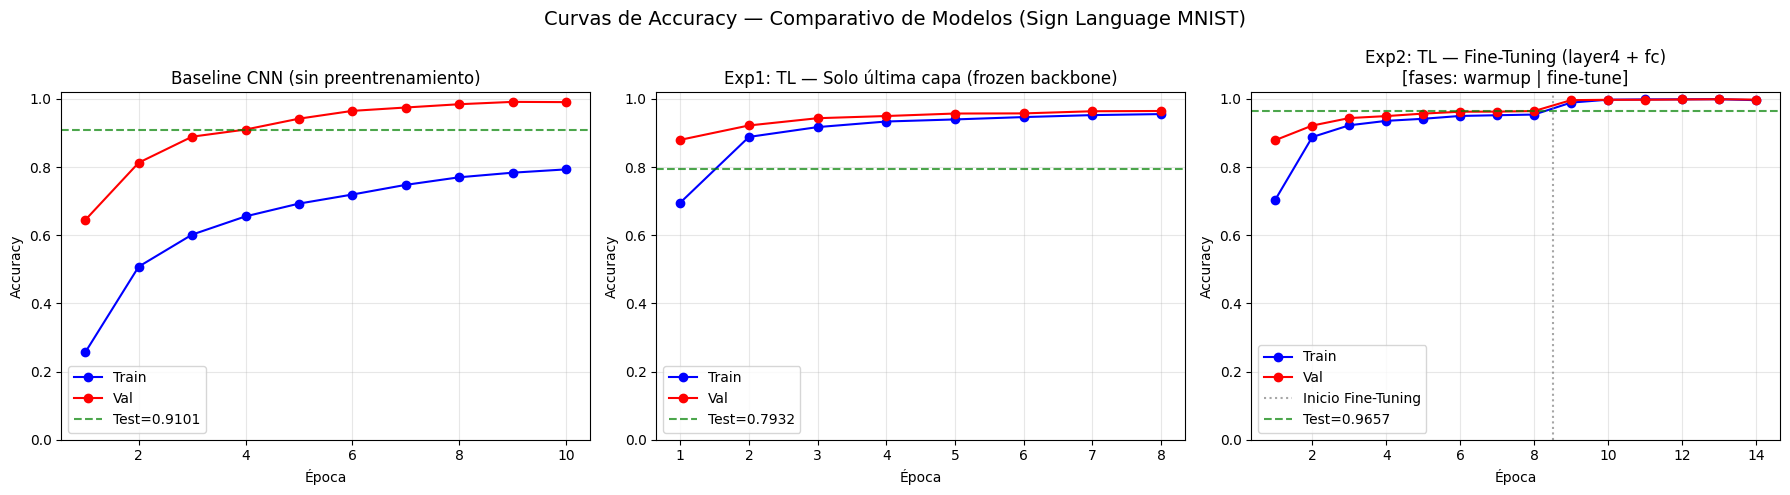

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Curvas de Accuracy — Comparativo de Modelos (Sign Language MNIST)", fontsize=14)

ax = axes[0]
epochs_b = range(1, len(h_base["train_acc"]) + 1)
ax.plot(epochs_b, h_base["train_acc"], "b-o", label="Train")
ax.plot(epochs_b, h_base["val_acc"],   "r-o", label="Val")
ax.axhline(R["baseline"]["test_acc"], color="green", linestyle="--", alpha=0.7, label=f"Test={R['baseline']['test_acc']:.4f}")
ax.set_title("Baseline CNN (sin preentrenamiento)")
ax.set_xlabel("Época"); ax.set_ylabel("Accuracy")
ax.legend(); ax.set_ylim(0, 1.02); ax.grid(True, alpha=0.3)

ax = axes[1]
epochs_e1 = range(1, len(h_exp1["train_acc"]) + 1)
ax.plot(epochs_e1, h_exp1["train_acc"], "b-o", label="Train")
ax.plot(epochs_e1, h_exp1["val_acc"],   "r-o", label="Val")
ax.axhline(R["exp1"]["test_acc"], color="green", linestyle="--", alpha=0.7, label=f"Test={R['exp1']['test_acc']:.4f}")
ax.set_title("Exp1: TL — Solo última capa (frozen backbone)")
ax.set_xlabel("Época"); ax.set_ylabel("Accuracy")
ax.legend(); ax.set_ylim(0, 1.02); ax.grid(True, alpha=0.3)

ax = axes[2]
exp2_tr_acc  = h_exp2a["train_acc"] + h_exp2b["train_acc"]
exp2_val_acc = h_exp2a["val_acc"]   + h_exp2b["val_acc"]
epochs_e2 = range(1, len(exp2_tr_acc) + 1)
ax.plot(epochs_e2, exp2_tr_acc,  "b-o", label="Train")
ax.plot(epochs_e2, exp2_val_acc, "r-o", label="Val")
ax.axvline(len(h_exp2a["val_acc"]) + 0.5, color="gray", linestyle=":", alpha=0.7, label="Inicio Fine-Tuning")
ax.axhline(R["exp2"]["test_acc"], color="green", linestyle="--", alpha=0.7, label=f"Test={R['exp2']['test_acc']:.4f}")
ax.set_title("Exp2: TL — Fine-Tuning (layer4 + fc)\n[fases: warmup | fine-tune]")
ax.set_xlabel("Época"); ax.set_ylabel("Accuracy")
ax.legend(); ax.set_ylim(0, 1.02); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
## 10. Análisis comparativo

### 10.1 Resultados

| Modelo | Train Acc | Val Acc | Test Acc | Épocas | Paráms entrenables |
|--------|-----------|---------|----------|--------|-------------------|
| Baseline CNN | 79.33% | 99.07% | **91.01%** | 10 | ~2.2M (100%) |
| Exp1: solo última capa | 95.56% | 96.47% | **79.32%** | 8 | 12 312 (0.11%) |
| Exp2: fine-tuning (layer4+fc) | 99.64% | 99.80% | **96.57%** | 14 (8+6) | 8.4M (75.1%) |

---

### 10.2 Train vs Validation accuracy

**Baseline CNN:** El gap entre train (79%) y val (99%) parece raro a primera vista, pero se explica por el data augmentation aplicado solo al train (flip horizontal + rotaciones). Las imágenes de entrenamiento se vuelven más difíciles, así que el modelo llega a val con peor accuracy de train aunque generalice bien. El test cae a 91%, lo que sugiere que hay algo de diferencia de distribución entre splits.

**Experimento 1:** Train y val son muy parecidas (95.6% vs 96.5%), la convergencia es limpia. El problema está en el test: 79.32%. El backbone de ResNet entrenado en fotos naturales de ImageNet no capta bien los patrones de manos en escala de grises, y la única capa que aprenda (el `fc`) no alcanza a compensarlo.

**Experimento 2:** La fase B es lo más llamativo: en la primera época de fine-tuning el modelo pasa de ~96% a ~99.8% de val accuracy. Train y val quedan prácticamente iguales (99.64% vs 99.80%), lo que indica que el modelo generaliza bien. El test de 96.57% confirma que la adaptación del backbone funciona.

---

### 10.3 Transfer Learning vs CNN desde cero

| Aspecto | Baseline CNN | TL sin FT (Exp1) | TL con FT (Exp2) |
|---------|-------------|-----------------|-----------------|
| Velocidad de convergencia | Lenta | Rápida (88% en época 1) | Muy rápida en Fase B |
| Punto de partida | Pesos aleatorios | Features ImageNet | Features ImageNet |
| Adaptación al dominio | Total | Ninguna | Alta (layer4 re-entrenada) |
| Test Accuracy | 91.01% | 79.32% ❌ | 96.57% ✅ |

El resultado más contraintuitivo: el TL **sin** fine-tuning fue peor que la CNN propia (79% vs 91%). El dominio de Sign Language MNIST (manos en escala de grises, 28×28) es muy distinto a ImageNet. Las features congeladas no son las más útiles para este problema, y el `fc` solo no alcanza a compensarlo.

Con fine-tuning la historia cambia: Exp2 supera al Baseline en 5.5 puntos, porque `layer4` puede ajustar sus filtros al dominio nuevo mientras las capas anteriores mantienen el conocimiento general.

---

### 10.4 Entrenar solo la última capa vs. entrenar más capas

**Exp1 — solo `fc`:**
- Ventaja: rapidísimo (~35s/época), 12K parámetros, sin overfitting
- Problema: las representaciones del backbone no se adaptan → test 79%
- Tiene sentido cuando el dominio destino es parecido al de origen (ej: clasificar otro tipo de fotos naturales con una base ImageNet)

**Exp2 — `layer4` + `fc`:**
- Test 96.57%, convergencia más rápida, gap val→test de solo 3 puntos vs 17 de Exp1
- El costo es mayor (~130s/época en Fase B) y hay que hacer el warm-up previo sí o sí
- Necesario cuando el dominio destino es distinto, como acá

El indicador más claro es el gap val→test: −17pp en Exp1 vs −3pp en Exp2. Con el backbone congelado el modelo aprende un mapeo frágil desde features que no son las ideales. Con fine-tuning, el modelo realmente entiende el problema.

---

### 10.5 Conclusión

El fine-tuning (Exp2) es la estrategia que mejor funciona para este dataset, con **96.57% de test accuracy** en 14 épocas totales. El TL sin fine-tuning puede ser útil cuando los dominios son similares, pero cuando no lo son, congelar el backbone completo puede ser peor que entrenar desde cero.
